# IndiGo Route Profitability & Network Expansion Intelligence

## Phase 1: IndiGo Network Data Preparation

### Objectives
- Load airline datasets
- Extract only IndiGo routes
- Validate route data
- Create IndiGo master route dataset
- Identify key hubs and route coverage
- Prepare data for profitability analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [ ]:
airport_cols = [
    "Airport_ID","Airport_Name","City","Country",
    "IATA","ICAO","Latitude","Longitude",
    "Altitude","Timezone","DST",
    "Tz_Database_Timezone","Type","Source"
]

airports = pd.read_csv(
    "airports.dat",
    header=None,
    names=airport_cols
)

airports.head()

,Airport_ID,Airport_Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz_Database_Timezone,Type,Source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [ ]:
airline_cols = [
    "Airline_ID","Airline_Name","Alias",
    "IATA","ICAO","Callsign",
    "Country","Active"
]

airlines = pd.read_csv(
    "airlines.dat",
    header=None,
    names=airline_cols
)

airlines.head()

,Airline_ID,Airline_Name,Alias,IATA,ICAO,Callsign,Country,Active
0,-1,Unknown,\N,-,NaN,\N,\N,Y
1,1,Private flight,\N,-,NaN,NaN,NaN,Y
2,2,135 Airways,\N,NaN,GNL,GENERAL,United States,N
3,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
4,4,2 Sqn No 1 Elementary Flying Training School,\N,NaN,WYT,NaN,United Kingdom,N


In [ ]:
route_cols = [
    "Airline",
    "Airline_ID",
    "Source_Airport",
    "Source_Airport_ID",
    "Destination_Airport",
    "Destination_Airport_ID",
    "Codeshare",
    "Stops",
    "Equipment"
]

routes = pd.read_csv(
    "routes.dat",
    header=None,
    names=route_cols
)

routes.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


In [ ]:
print("Airports Shape :", airports.shape)
print("Airlines Shape :", airlines.shape)
print("Routes Shape :", routes.shape)

Airports Shape : (7698, 14)
Airlines Shape : (6162, 8)
Routes Shape : (67663, 9)


In [ ]:
indigo = airlines[
    (airlines["IATA"] == "6E") |
    (airlines["ICAO"] == "IGO")
]

indigo

,Airline_ID,Airline_Name,Alias,IATA,ICAO,Callsign,Country,Active
2848,2850,IndiGo Airlines,\N,6E,IGO,IFLY,India,Y


In [ ]:
indigo_id = int(indigo["Airline_ID"].iloc[0])

print("IndiGo Airline ID:", indigo_id)

IndiGo Airline ID: 2850


In [ ]:
routes["Airline_ID"] = pd.to_numeric(
    routes["Airline_ID"],
    errors="coerce"
)

routes["Source_Airport_ID"] = pd.to_numeric(
    routes["Source_Airport_ID"],
    errors="coerce"
)

routes["Destination_Airport_ID"] = pd.to_numeric(
    routes["Destination_Airport_ID"],
    errors="coerce"
)

In [ ]:
indigo_routes = routes[
    routes["Airline_ID"] == indigo_id
].copy()

indigo_routes.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment
2115,6E,2850.0,AMD,2994.0,BLR,3131.0,NaN,0,320
2116,6E,2850.0,AMD,2994.0,BOM,2997.0,NaN,0,320
2117,6E,2850.0,AMD,2994.0,CCU,3043.0,NaN,0,320
2118,6E,2850.0,AMD,2994.0,DEL,3093.0,NaN,0,320
2119,6E,2850.0,AMD,2994.0,GOI,3007.0,NaN,0,320


In [ ]:
print("Total IndiGo Routes:", len(indigo_routes))

Total IndiGo Routes: 227


In [ ]:
indigo_routes.isnull().sum()

,0
Airline,0
Airline_ID,0
Source_Airport,0
Source_Airport_ID,14
Destination_Airport,0
Destination_Airport_ID,14
Codeshare,227
Stops,0
Equipment,0


In [ ]:
print(
    "Duplicate Routes:",
    indigo_routes.duplicated().sum()
)

Duplicate Routes: 0


In [ ]:
indigo_routes = indigo_routes.drop_duplicates()

In [ ]:
airports["Airport_ID"] = pd.to_numeric(
    airports["Airport_ID"],
    errors="coerce"
)

In [ ]:
valid_airports = set(
    airports["Airport_ID"]
)

indigo_routes = indigo_routes[
    indigo_routes["Source_Airport_ID"]
    .isin(valid_airports)
]

indigo_routes = indigo_routes[
    indigo_routes["Destination_Airport_ID"]
    .isin(valid_airports)
]

print("Valid IndiGo Routes:", len(indigo_routes))

Valid IndiGo Routes: 199


In [ ]:
airports_clean = airports[
    [
        "Airport_ID",
        "Airport_Name",
        "City",
        "Country",
        "Latitude",
        "Longitude"
    ]
].copy()

airports_clean.head()

,Airport_ID,Airport_Name,City,Country,Latitude,Longitude
0,1,Goroka Airport,Goroka,Papua New Guinea,-6.081690,145.391998
1,2,Madang Airport,Madang,Papua New Guinea,-5.207080,145.789001
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,-5.826790,144.296005
3,4,Nadzab Airport,Nadzab,Papua New Guinea,-6.569803,146.725977
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,-9.443380,147.220001


In [ ]:
source_airports = airports_clean.rename(
    columns={
        "Airport_ID":"Source_Airport_ID",
        "Airport_Name":"Source_Airport_Name",
        "City":"Source_City",
        "Country":"Source_Country",
        "Latitude":"Source_Latitude",
        "Longitude":"Source_Longitude"
    }
)

In [ ]:
destination_airports = airports_clean.rename(
    columns={
        "Airport_ID":"Destination_Airport_ID",
        "Airport_Name":"Destination_Airport_Name",
        "City":"Destination_City",
        "Country":"Destination_Country",
        "Latitude":"Destination_Latitude",
        "Longitude":"Destination_Longitude"
    }
)

In [ ]:
indigo_master = indigo_routes.merge(
    source_airports,
    on="Source_Airport_ID",
    how="left"
)

indigo_master.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment,Source_Airport_Name,Source_City,Source_Country,Source_Latitude,Source_Longitude
0,6E,2850.0,AMD,2994.0,BLR,3131.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697
1,6E,2850.0,AMD,2994.0,BOM,2997.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697
2,6E,2850.0,AMD,2994.0,CCU,3043.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697
3,6E,2850.0,AMD,2994.0,DEL,3093.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697
4,6E,2850.0,AMD,2994.0,GOI,3007.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697


In [ ]:
indigo_master = indigo_master.merge(
    destination_airports,
    on="Destination_Airport_ID",
    how="left"
)

indigo_master.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment,Source_Airport_Name,Source_City,Source_Country,Source_Latitude,Source_Longitude,Destination_Airport_Name,Destination_City,Destination_Country,Destination_Latitude,Destination_Longitude
0,6E,2850.0,AMD,2994.0,BLR,3131.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Kempegowda International Airport,Bangalore,India,13.197900,77.706299
1,6E,2850.0,AMD,2994.0,BOM,2997.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Chhatrapati Shivaji International Airport,Mumbai,India,19.088699,72.867897
2,6E,2850.0,AMD,2994.0,CCU,3043.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Netaji Subhash Chandra Bose International Airport,Kolkata,India,22.654699,88.446701
3,6E,2850.0,AMD,2994.0,DEL,3093.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Indira Gandhi International Airport,Delhi,India,28.566500,77.103104
4,6E,2850.0,AMD,2994.0,GOI,3007.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Dabolim Airport,Goa,India,15.380800,73.831398


In [ ]:
indigo_master["Route"] = (
    indigo_master["Source_Airport_Name"]
    + " → " +
    indigo_master["Destination_Airport_Name"]
)

In [ ]:
indigo_master[
    [
        "Route",
        "Source_City",
        "Destination_City"
    ]
].head()

,Route,Source_City,Destination_City
0,Sardar Vallabhbhai Patel International Airport...,Ahmedabad,Bangalore
1,Sardar Vallabhbhai Patel International Airport...,Ahmedabad,Mumbai
2,Sardar Vallabhbhai Patel International Airport...,Ahmedabad,Kolkata
3,Sardar Vallabhbhai Patel International Airport...,Ahmedabad,Delhi
4,Sardar Vallabhbhai Patel International Airport...,Ahmedabad,Goa


In [ ]:
indigo_master["Route_Type"] = np.where(
    indigo_master["Source_Country"] ==
    indigo_master["Destination_Country"],
    "Domestic",
    "International"
)

indigo_master["Route_Type"].value_counts()

,count
Route_Type,
Domestic,179
International,20


In [ ]:
airports_served = pd.concat([
    indigo_master["Source_Airport_Name"],
    indigo_master["Destination_Airport_Name"]
]).nunique()

print("Airports Served:", airports_served)

Airports Served: 35


In [ ]:
hub_analysis = (
    indigo_master["Source_Airport_Name"]
    .value_counts()
    .reset_index()
)

hub_analysis.columns = [
    "Airport",
    "Outgoing_Routes"
]

hub_analysis.head(20)

,Airport,Outgoing_Routes
0,Indira Gandhi International Airport,26
1,Chhatrapati Shivaji International Airport,22
2,Netaji Subhash Chandra Bose International Airport,18
3,Kempegowda International Airport,15
4,Chennai International Airport,12
5,Sardar Vallabhbhai Patel International Airport,8
6,Lokpriya Gopinath Bordoloi International Airport,7
7,Pune Airport,6
8,Cochin International Airport,6
9,Dr. Babasaheb Ambedkar International Airport,6


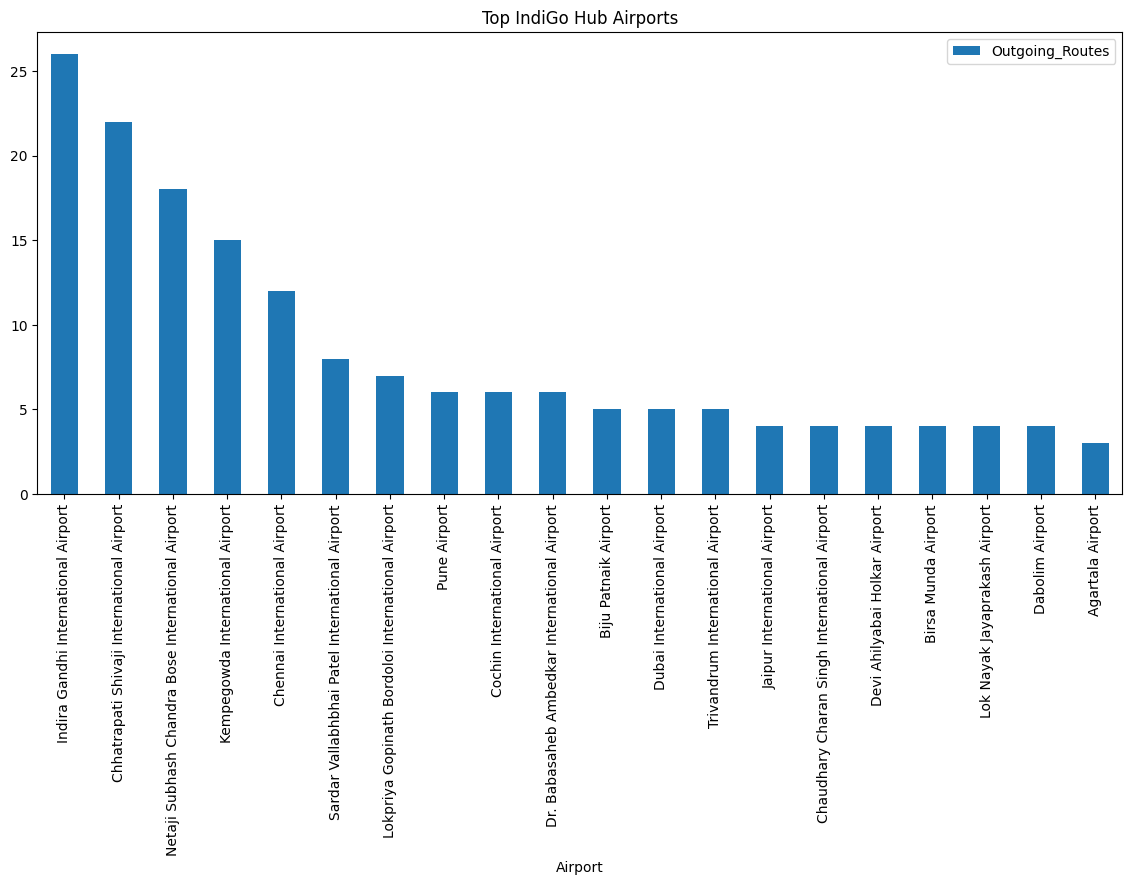

In [ ]:
hub_analysis.head(20).plot(
    x="Airport",
    y="Outgoing_Routes",
    kind="bar",
    figsize=(14,6)
)

plt.title("Top IndiGo Hub Airports")
plt.xticks(rotation=90)

plt.show()

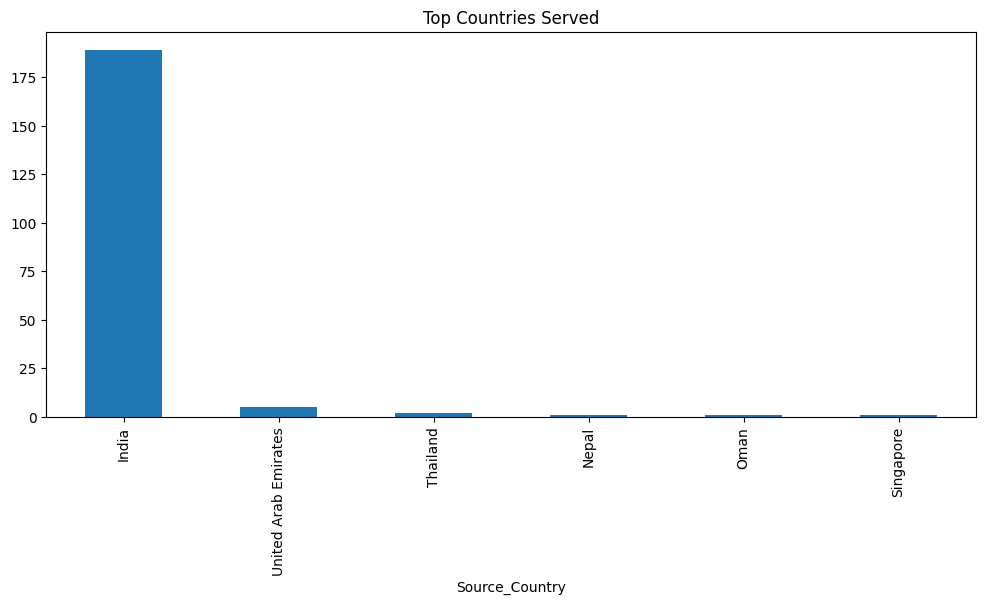

In [ ]:
indigo_master["Source_Country"]\
.value_counts()\
.head(15)\
.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Countries Served")
plt.show()

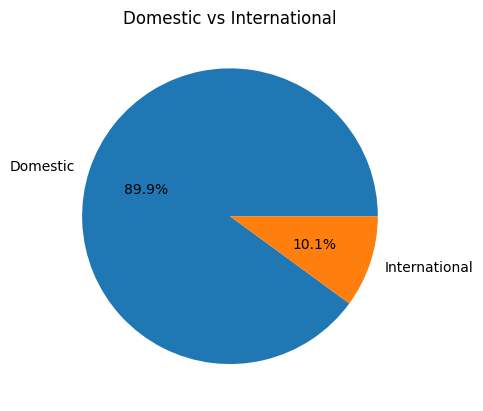

In [ ]:
indigo_master["Route_Type"]\
.value_counts()\
.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Domestic vs International")
plt.show()

In [ ]:
indigo_master.to_csv(
    "indigo_route_master.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
print("="*60)

print("INDIGO NETWORK DATA REPORT")

print("="*60)

print("Total IndiGo Routes:",
      len(indigo_master))

print("Airports Served:",
      airports_served)

print("Domestic Routes:",
      (indigo_master["Route_Type"]=="Domestic").sum())

print("International Routes:",
      (indigo_master["Route_Type"]=="International").sum())

print()

print("Top Hub Airport:")

print(
    hub_analysis.iloc[0]["Airport"]
)

print()

print("Dataset Ready For Phase 2")

print("="*60)

INDIGO NETWORK DATA REPORT
Total IndiGo Routes: 199
Airports Served: 35
Domestic Routes: 179
International Routes: 20

Top Hub Airport:
Indira Gandhi International Airport

Dataset Ready For Phase 2
